In [12]:
from sklearn.datasets import fetch_openml
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sys
sys.path.append('../')

In [3]:
from src.mean_stress import mean_stress_experiment

### Load data and train xgboost

In [4]:
# fetch the Adult dataset
data = fetch_openml(name="adult", version=2, as_frame=True)
df = data.frame

print(df.head())

   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  class  
0       

In [5]:
df.shape

(48842, 15)

In [6]:
df_new = df.copy()
df_new['class'] = df_new['class'].apply(lambda x: 1 if x == '>50K' else 0)
df_new.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0


In [7]:
model = XGBClassifier(
    tree_method="hist",        # faster histogram grower
    enable_categorical=True     # allow native categorical handling
)

In [8]:
X = df_new.drop('class', axis=1)
y = df_new['class']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test set
    random_state=0,    # reproducibility
    stratify=y          # important for classification
)


In [10]:
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### run stress experiment constraining "age" on X_test

In [11]:
taus = np.linspace(-1,1,21)
feature = "age"

In [12]:
X_test.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object')

In [13]:
results, projected_means = mean_stress_experiment(
    model,
    X_test,
    feature,
    taus,
    alpha=0.05
)

### plotting results

In [14]:
from src.plotting import plot_mean_stress

In [15]:
from src.stress_base import compute_quantile_bounds

In [16]:
m, q_low, q_high = compute_quantile_bounds(X_test['age'].values, alpha=0.05)

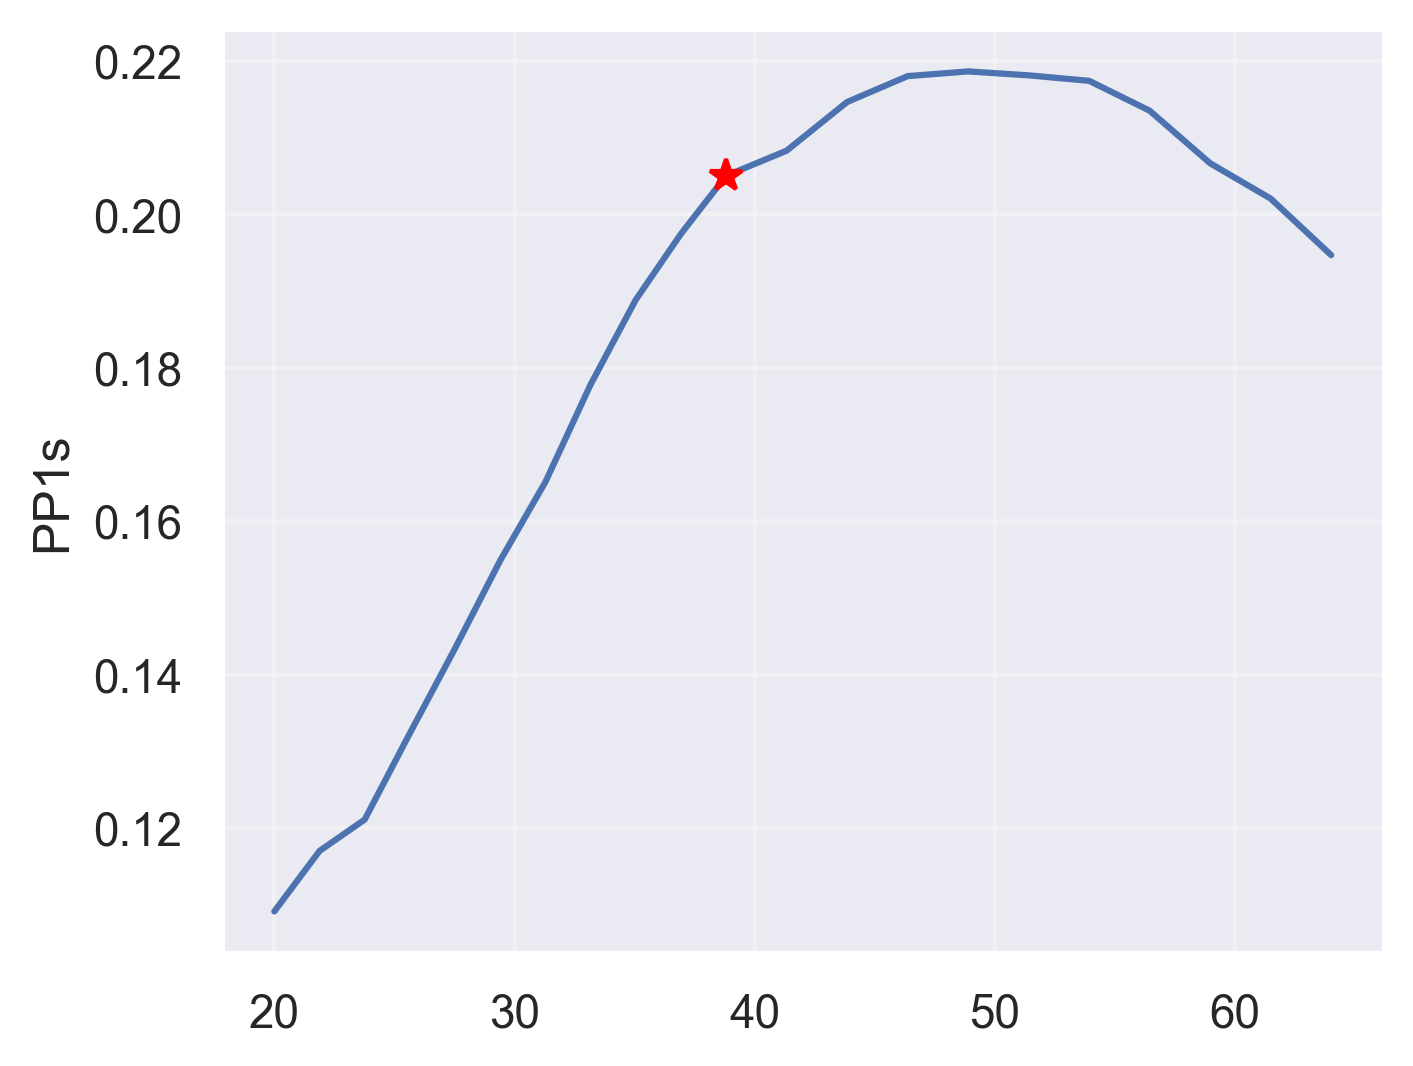

In [18]:
plot_mean_stress(
    projected_means,
    results[:,1],
    base_mean=m
)

### stressing two means simultaneously

In [11]:
from src.plotting import plot_twomeans

In [12]:
X_test.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object')

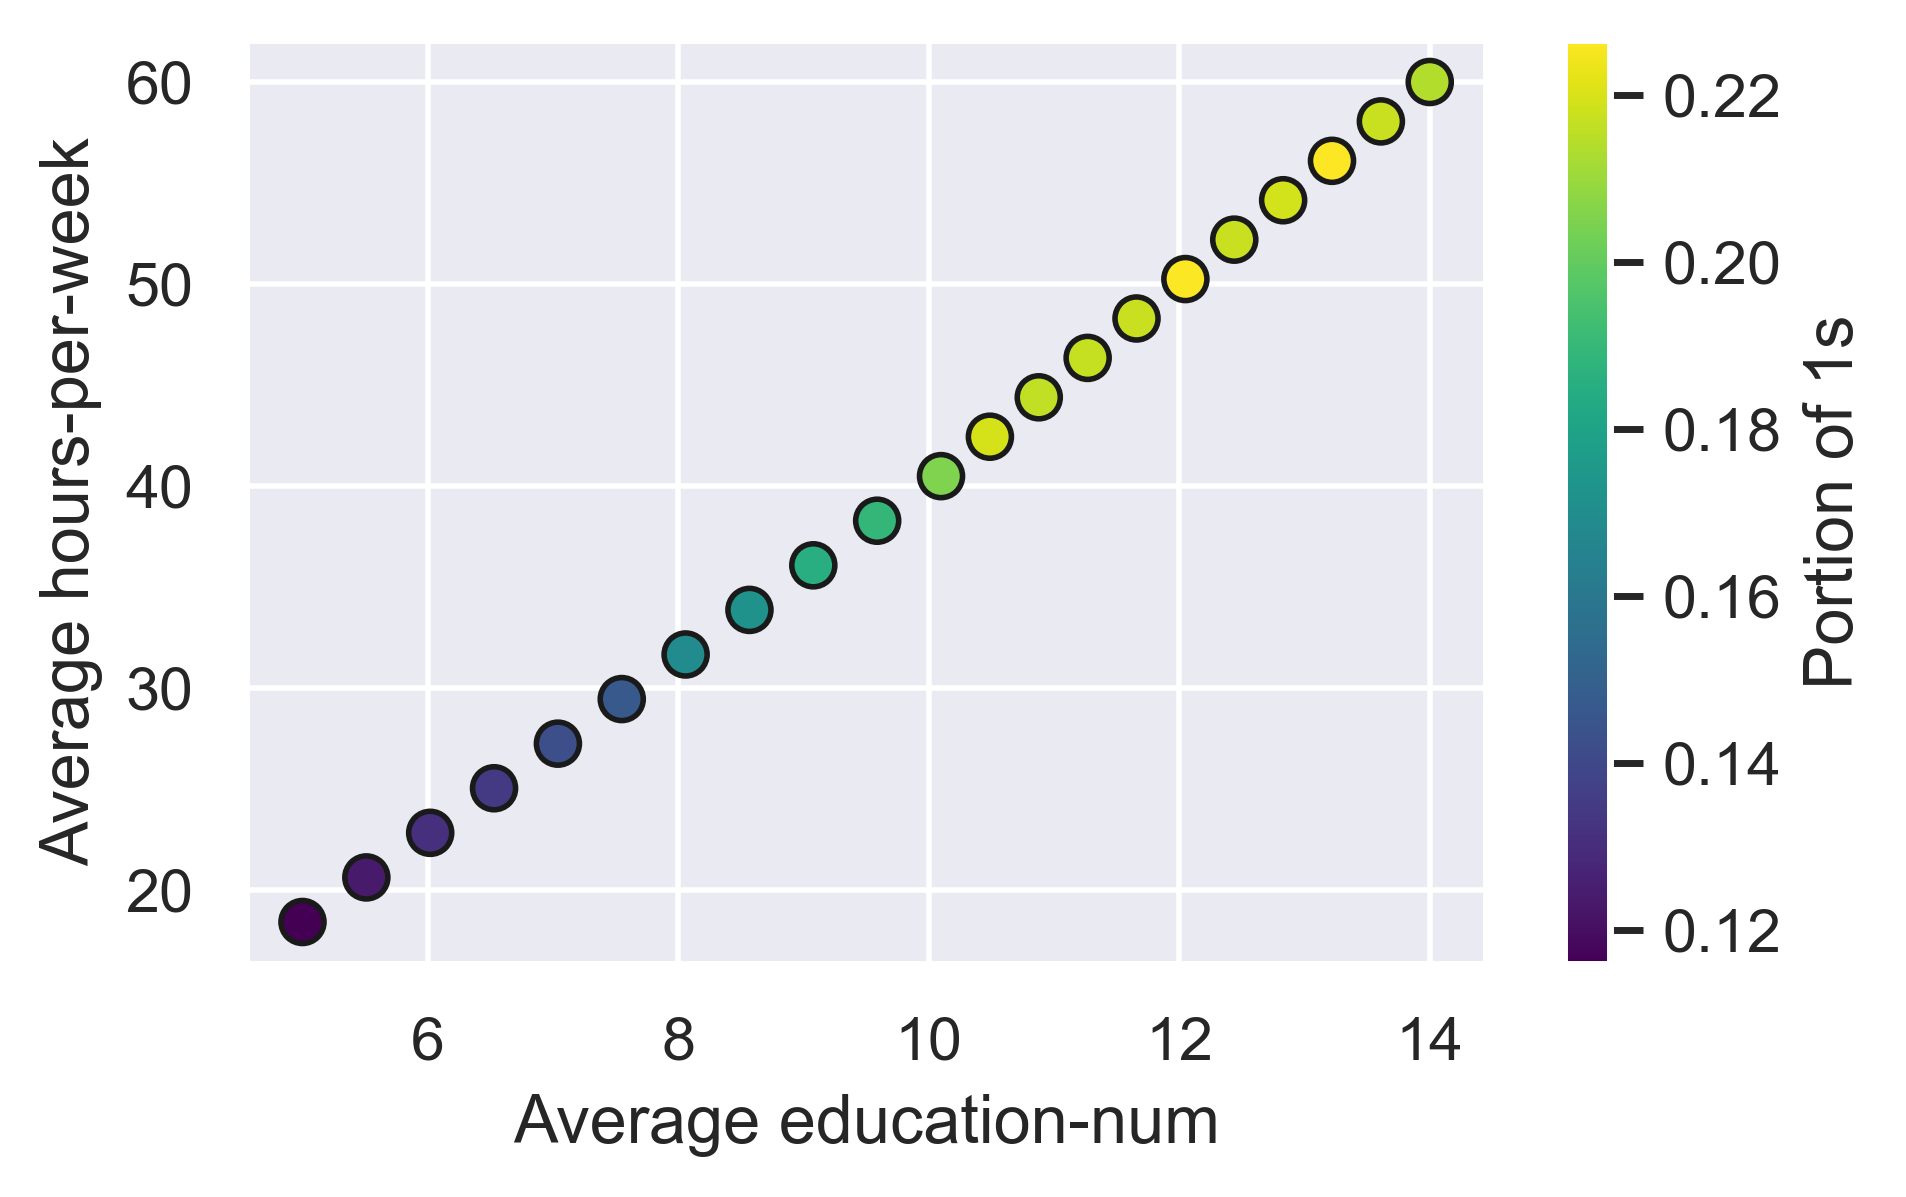

In [13]:
taus = np.linspace(-1,1,21)

plot_twomeans(
    X_test,
    "education-num",
    "hours-per-week",
    taus,
    model,
    alpha=0.05,
)

### ploting multiple means for gradientboosting

In [3]:
from LEFkit.data import LoadAndTreatAdultCensus

data_ohe = LoadAndTreatAdultCensus.get_treated_dataframe(verbose=False)

X_raw_col_names=data_ohe.columns

In [4]:
X = data_ohe.drop('Target', axis = 1)
Y = data_ohe['Target']
X_train, X_test , y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [5]:
from sklearn.ensemble import GradientBoostingClassifier

clf_GB=GradientBoostingClassifier()

In [6]:
clf_GB.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [7]:
from src.mean_stress import plot_multiplemean

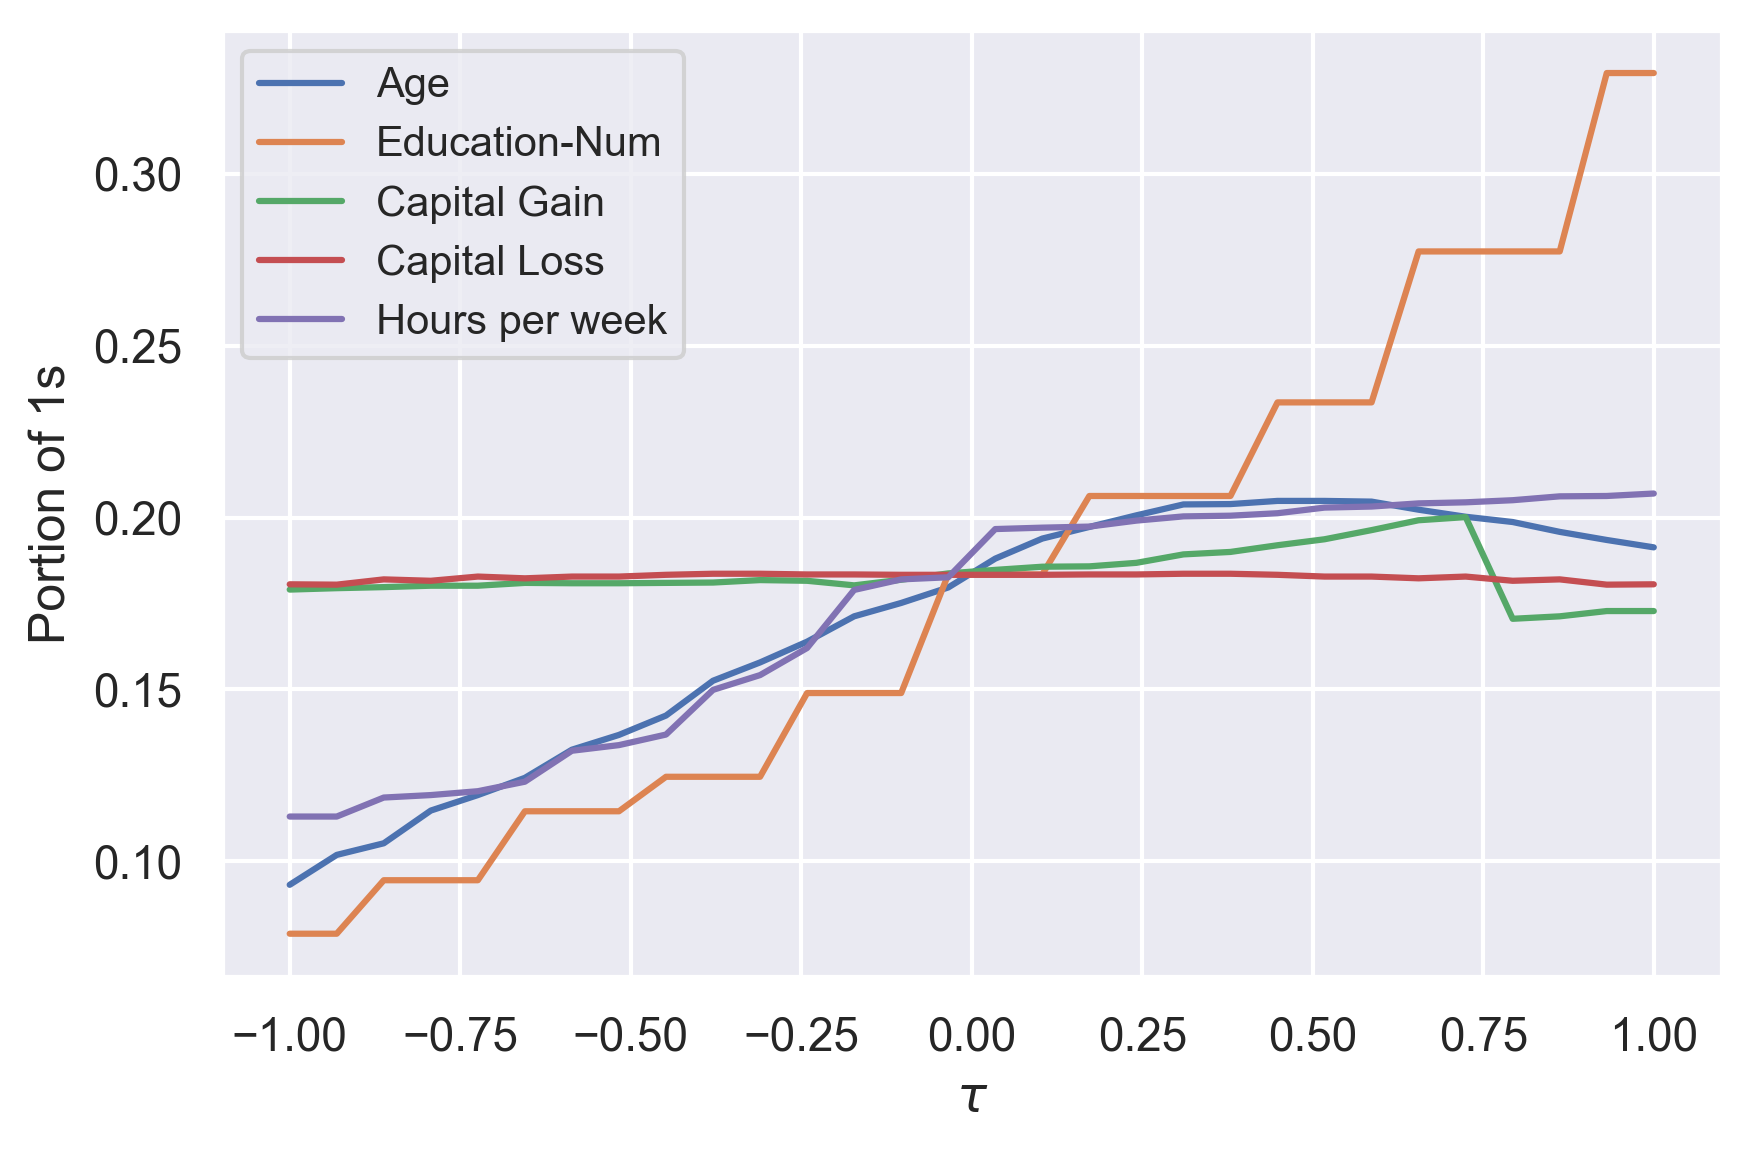

In [8]:
taus = np.linspace(-1,1,30)

fig = plot_multiplemean(X_test, taus, clf_GB, alpha = 0.05)

### DI: fairwashing

In [7]:
X_col_names = list(X_train.columns)
X_col_names.index('Gender')

3

In [8]:
X=X_test.values
S = X[:,X_col_names.index('Gender')].ravel()

In [9]:
x_train = X_train
x_test = X_test
y_train = y_train 
col_name = 'Capital Gain'

In [10]:
from src.mean_stress import di_stress_experiment
from src.plotting import plot_di

In [13]:
taus = np.linspace(-1,1,21)

proj_means, dis, lower, upper = di_stress_experiment(
    x_test,
    col_name,
    taus,
    clf_GB,
    alpha=0.05,
    S=S
)

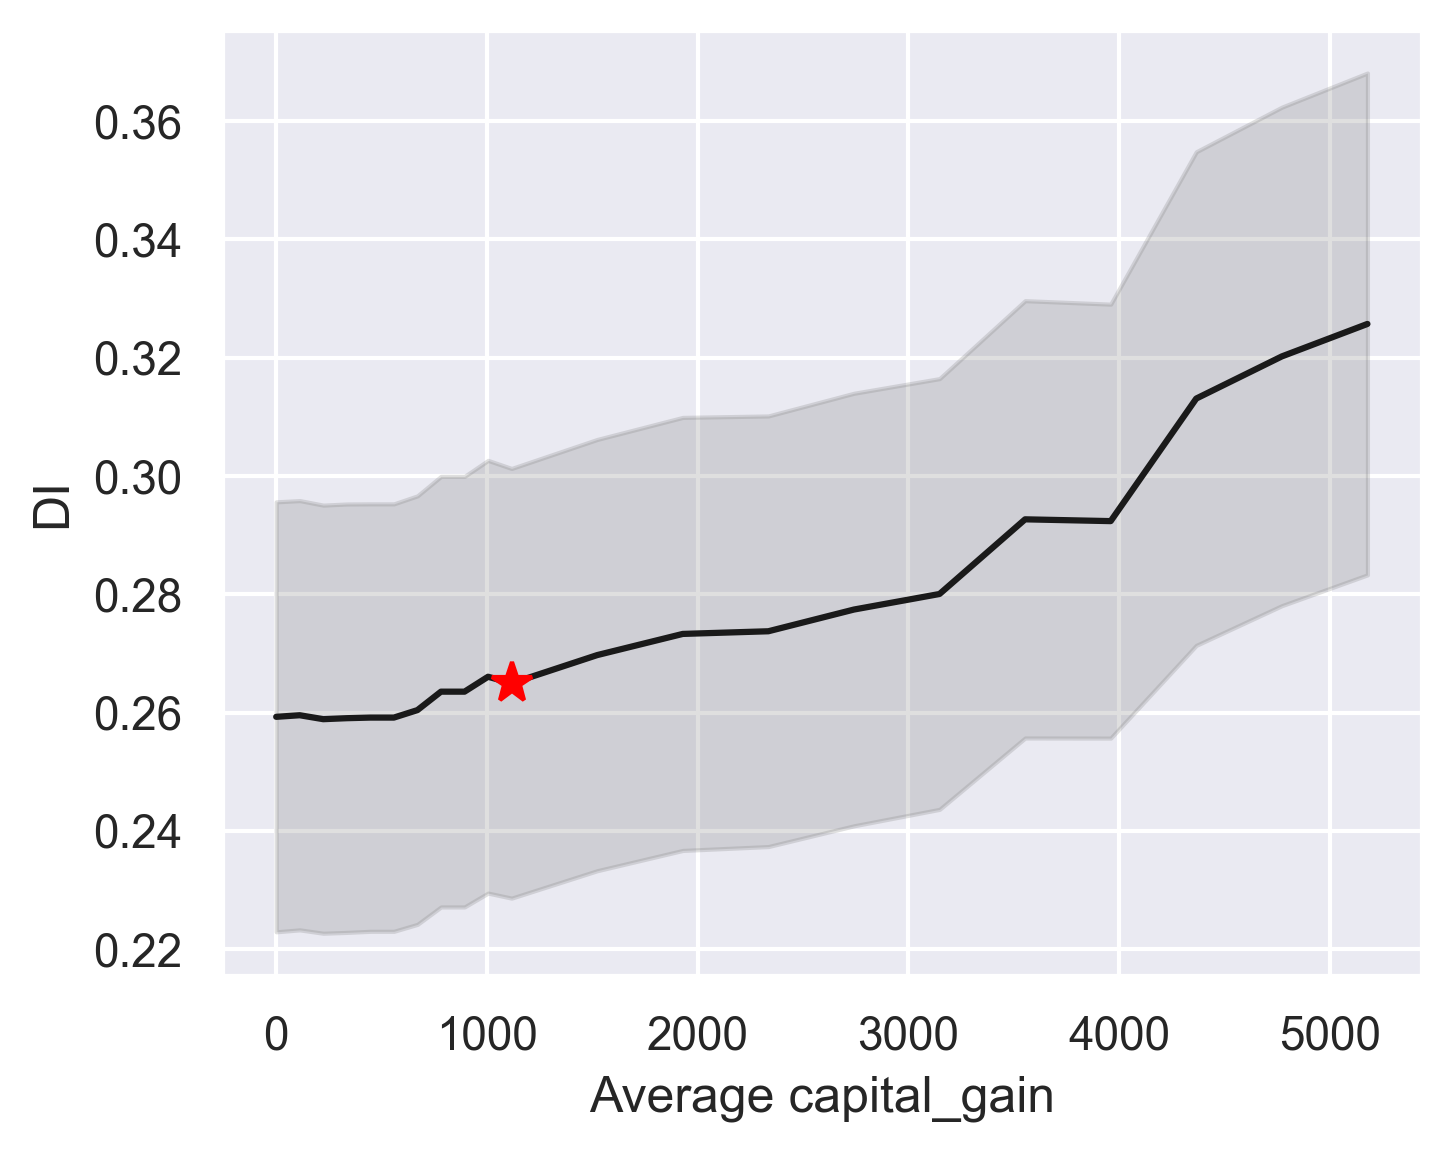

In [14]:
plot_di(
    proj_means,
    dis,
    lower,
    upper,
    "capital_gain",
    taus
)